In [1]:
# Cell 1: Infrastructure and Device Mapping
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# Enforce hardware acceleration for high-dimensional information space
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"FRAE-S Kinetic Engine Initialized on: {device}")

FRAE-S Kinetic Engine Initialized on: cpu


In [2]:
# Cell 2: The Fluid Resonance Advantage Estimation - Stable (FRAE-S)
def compute_fraes_advantages(rewards, values, dones, gamma=0.99, alpha=0.01, re_crit=2.0, beta_laminar=0.95, eps=1e-8):
    """
    Computes the FRAE-S governed by the Information Reynolds Number.
    Assumes 1D tensors of shape (T,) for a single continuous trajectory.
    """
    T = rewards.shape[0]

    # 1. Raw Temporal Difference Errors (The Input Energy)
    # values length is T+1 to bootstrap the final state
    deltas = rewards + gamma * values[1:] * (1 - dones) - values[:-1]

    zetas = torch.zeros_like(deltas)
    betas = torch.zeros_like(deltas)
    re_infos = torch.zeros_like(deltas)

    # 2. Forward Pass: Causal Sensor Phase
    current_var = torch.tensor(eps, device=device)
    prev_delta = torch.tensor(0.0, device=device)

    for t in range(T):
        # Kinetic Energy of the TD-Error (Variance EMA)
        current_var = (1 - alpha) * current_var + alpha * (deltas[t] ** 2)
        zeta_t = torch.sqrt(current_var) + eps
        zetas[t] = zeta_t

        # Information Reynolds Number (Inertial Momentum / Viscous Stability)
        momentum = torch.abs(deltas[t] - prev_delta)
        re_info = momentum / zeta_t
        re_infos[t] = re_info

        # Navier-Stokes Phase Transition Switch: Exponential Hysteresis
        # As Re_info spikes, beta gracefully collapses. No more fluttering.
        # beta_t = beta_laminar * e^(- (Re / Re_crit)^2 )
        decay_factor = torch.exp(- (re_info / re_crit)**2 )
        betas[t] = beta_laminar * decay_factor

        prev_delta = deltas[t]

    # 3. Backward Pass: Fluid Advantage Energy Flow
    advantages = torch.zeros_like(deltas)
    U_next = torch.tensor(0.0, device=device)

    for t in reversed(range(T)):
        # U_t = δ_t + γ * β_t * U_{t+1}
        U_t = deltas[t] + gamma * betas[t] * (1 - dones[t]) * U_next

        # Apply the Fierce Stability Sink
        advantages[t] = U_t / zetas[t]

        U_next = U_t

    return advantages, betas, zetas, re_infos

In [3]:
# Cell 3: The Actor-Critic Architecture (Decoupled)
class A2CNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_size=64):
        super(A2CNetwork, self).__init__()

        # Actor: The Policy mapping states to action probabilities
        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, action_dim)
        )

        # Critic: The Value network mapping states to expected returns
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        logits = self.actor(x)
        value = self.critic(x)
        return logits, value

    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        probs = torch.distributions.Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(x)

In [4]:
# Cell 4: The Fluid Rollout Buffer
class FluidRolloutBuffer:
    def __init__(self, num_steps, obs_dim, device):
        self.num_steps = num_steps
        self.device = device

        # Standard RL memory
        self.obs = torch.zeros((num_steps, obs_dim), dtype=torch.float32).to(device)
        self.actions = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.logprobs = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.rewards = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.dones = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.values = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.entropies = torch.zeros((num_steps,), dtype=torch.float32).to(device)

        self.step = 0

    def add(self, obs, action, logprob, reward, done, value, entropy):
        self.obs[self.step] = obs
        self.actions[self.step] = action
        self.logprobs[self.step] = logprob
        self.rewards[self.step] = reward
        self.dones[self.step] = done
        self.values[self.step] = value
        self.entropies[self.step] = entropy
        self.step += 1

    def compute_returns_and_advantages(self, next_value, done_flag, gamma=0.99, alpha=0.01, re_crit=2.0, beta_laminar=0.95):
        # We must append the final bootstrap value to align with Cell 2's logic
        full_values = torch.cat([self.values, next_value.view(-1)]).to(self.device)

        # Trigger the Navier-Stokes FRAE-S Engine (from Cell 2)
        advantages, betas, zetas, re_infos = compute_fraes_advantages(
            rewards=self.rewards,
            values=full_values,
            dones=self.dones,
            gamma=gamma,
            alpha=alpha,
            re_crit=re_crit,
            beta_laminar=beta_laminar
        )

        # The true target return is the Advantage + Value
        returns = advantages + self.values

        self.step = 0 # Reset for next rollout
        return returns, advantages, betas, zetas, re_infos

In [5]:
# Cell 5: The Core FRAE-S Training Loop
import torch.optim as optim

def train_fraes_agent(env_name="CartPole-v1", total_epochs=500, steps_per_epoch=200):
    env = gym.make(env_name)
    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Initialize the Isolated Architecture
    network = A2CNetwork(obs_dim, action_dim).to(device)
    optimizer = optim.Adam(network.parameters(), lr=0.001)

    # Initialize the Fluid Buffer
    buffer = FluidRolloutBuffer(steps_per_epoch, obs_dim, device)

    # Telemetry storage for Cell 6
    history = {
        'rewards': [], 'policy_loss': [], 'value_loss': [],
        'mean_beta': [], 'mean_zeta': [], 'max_re_info': []
    }

    obs, _ = env.reset()

    print(f"Initiating FRAE-S Training on {env_name} | Target Epochs: {total_epochs}")

    for epoch in range(total_epochs):
        epoch_reward = 0

        # 1. Rollout Phase
        for step in range(steps_per_epoch):
            obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)

            with torch.no_grad():
                action, logprob, entropy, value = network.get_action_and_value(obs_tensor)

            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            epoch_reward += reward

            # Store in buffer
            buffer.add(obs_tensor, action, logprob, reward, done, value.squeeze(), entropy)

            obs = next_obs if not done else env.reset()[0]

        # 2. Physics Phase (The Navier-Stokes Computation)
        next_obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)
        with torch.no_grad():
            _, _, _, next_value = network.get_action_and_value(next_obs_tensor)

        returns, advantages, betas, zetas, re_infos = buffer.compute_returns_and_advantages(
            next_value.squeeze(), done_flag=done,
            gamma=0.99, alpha=0.01, re_crit=2.0, beta_laminar=0.95
        )

        # 3. Gradient Phase
        # Re-evaluate log_probs and values for the computation graph
        _, logprobs, entropies, values = network.get_action_and_value(buffer.obs, buffer.actions)
        values = values.squeeze()

        # CRITICAL: We do NOT normalize advantages here. \zeta_t already did it physically.
        policy_loss = -(logprobs * advantages).mean()

        # The Huber Ceiling: Protects the Critic from topological gradient explosions
        value_loss = torch.nn.functional.smooth_l1_loss(values, returns)

        entropy_loss = -0.01 * entropies.mean() # Small entropy bonus for exploration

        loss = policy_loss + value_loss + entropy_loss

        optimizer.zero_grad()
        loss.backward()
        # Clip gradients to prevent early catastrophic shattering
        torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=0.5)
        optimizer.step()

        # 4. Telemetry Logging
        history['rewards'].append(epoch_reward)
        history['policy_loss'].append(policy_loss.item())
        history['value_loss'].append(value_loss.item())
        history['mean_beta'].append(betas.mean().item())
        history['mean_zeta'].append(zetas.mean().item())
        history['max_re_info'].append(re_infos.max().item())

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:03d} | Reward: {epoch_reward:03.1f} | Re_max: {re_infos.max().item():.2f} | Zeta: {zetas.mean().item():.3f} | Beta: {betas.mean().item():.2f}")

    env.close()
    return network, history

# Execute the training
trained_model, fraes_history = train_fraes_agent(total_epochs=300, steps_per_epoch=200)

Initiating FRAE-S Training on CartPole-v1 | Target Epochs: 300


KeyboardInterrupt: 

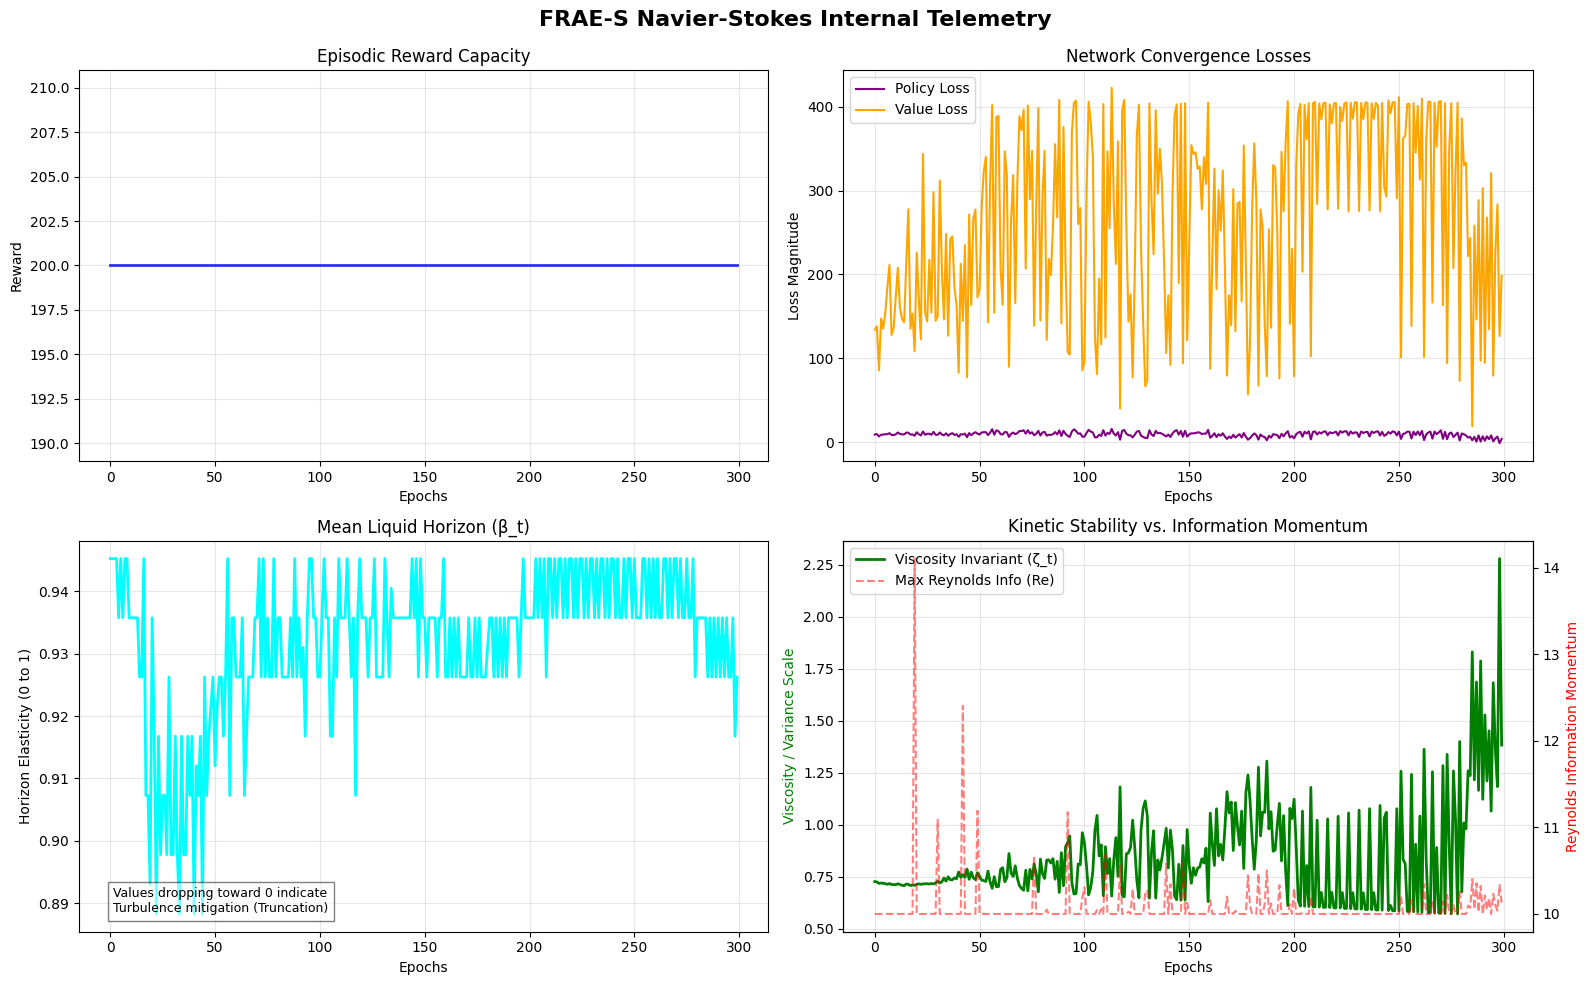

In [6]:
# Cell 6: Physics-Informed Telemetry Visualization
def plot_fraes_telemetry(history):
    epochs = np.arange(len(history['rewards']))

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("FRAE-S Navier-Stokes Internal Telemetry", fontsize=16, fontweight='bold')

    # Plot 1: Standard Reward (Did it learn?)
    axs[0, 0].plot(epochs, history['rewards'], color='blue', alpha=0.8, linewidth=2)
    axs[0, 0].set_title("Episodic Reward Capacity")
    axs[0, 0].set_xlabel("Epochs")
    axs[0, 0].set_ylabel("Reward")
    axs[0, 0].grid(True, alpha=0.3)

    # Plot 2: Network Losses
    axs[0, 1].plot(epochs, history['policy_loss'], label="Policy Loss", color='purple')
    axs[0, 1].plot(epochs, history['value_loss'], label="Value Loss", color='orange')
    axs[0, 1].set_title("Network Convergence Losses")
    axs[0, 1].set_xlabel("Epochs")
    axs[0, 1].set_ylabel("Loss Magnitude")
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    # Plot 3: The Navier-Stokes Fluidity (\beta_t)
    axs[1, 0].plot(epochs, history['mean_beta'], color='cyan', linewidth=2)
    axs[1, 0].set_title("Mean Liquid Horizon (β_t)")
    axs[1, 0].set_xlabel("Epochs")
    axs[1, 0].set_ylabel("Horizon Elasticity (0 to 1)")
    axs[1, 0].text(0.05, 0.05, "Values dropping toward 0 indicate\nTurbulence mitigation (Truncation)",
                   transform=axs[1, 0].transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.5))
    axs[1, 0].grid(True, alpha=0.3)

    # Plot 4: The Stability Sink & Information Momentum
    ax4_twin = axs[1, 1].twinx()
    l1 = axs[1, 1].plot(epochs, history['mean_zeta'], color='green', label="Viscosity Invariant (ζ_t)", linewidth=2)
    l2 = ax4_twin.plot(epochs, history['max_re_info'], color='red', alpha=0.5, label="Max Reynolds Info (Re)", linestyle='--')

    axs[1, 1].set_title("Kinetic Stability vs. Information Momentum")
    axs[1, 1].set_xlabel("Epochs")
    axs[1, 1].set_ylabel("Viscosity / Variance Scale", color='green')
    ax4_twin.set_ylabel("Reynolds Information Momentum", color='red')

    # Combine legends for twin axes
    lns = l1 + l2
    labs = [l.get_label() for l in lns]
    axs[1, 1].legend(lns, labs, loc='upper left')
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Render the physical state of the intelligence
plot_fraes_telemetry(fraes_history)

In [7]:
# Cell 7: FRAE-S Deployment in High-Turbulence Environment
# (Run this to install the Box2D physics engine if not already present)
!pip install -q gymnasium[box2d]

print("Deploying FRAE-S Architecture to LunarLander-v2...")

# We use the exact same training function we built in Cell 5.
# The network dimensions will dynamically adjust to 8 inputs and 4 outputs.
ll_model, ll_history = train_fraes_agent(
    env_name="LunarLander-v3",
    total_epochs=1000,
    steps_per_epoch=500
)

print("LunarLander Training Complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 84.4 MB/s eta 0:00:00
Deploying FRAE-S Architecture to LunarLander-v2...
Initiating FRAE-S Training on LunarLander-v3 | Target Epochs: 1000
Epoch 050 | Reward: -522.8 | Re_max: 10.00 | Zeta: 6.654 | Beta: 0.90
Epoch 100 | Reward: -385.7 | Re_max: 14.14 | Zeta: 7.620 | Beta: 0.91
Epoch 150 | Reward: -163.2 | Re_max: 10.00 | Zeta: 5.842 | Beta: 0.90
Epoch 200 | Reward: 89.4 | Re_max: 10.94 | Zeta: 5.666 | Beta: 0.86
Epoch 250 | Reward: -13.5 | Re_max: 11.96 | Zeta: 4.830 | Beta: 0.86
Epoch 300 | Reward: 54.9 | Re_max: 13.82 | Zeta: 6.358 | Beta: 0.92
Epoch 350 | Reward: -41.6 | Re_max: 13.92 | Zeta: 3.370 | Beta: 0.81
Epoch 400 | Reward: 144.9 | Re_max: 10.00 | Zeta: 6.448 | Beta: 0.89
Epoch 450 | Reward: -84.4 | Re_max: 12.33 | Zeta: 2.064 | Beta: 0.84
Epoch 500 | Reward: -48.0 | Re_max: 10.00 | Zeta: 3.866 | Beta: 0.88
Epoch 550 | Reward: -12.7 | Re_max: 1

Rendering FRAE-S Physics Telemetry for LunarLander...


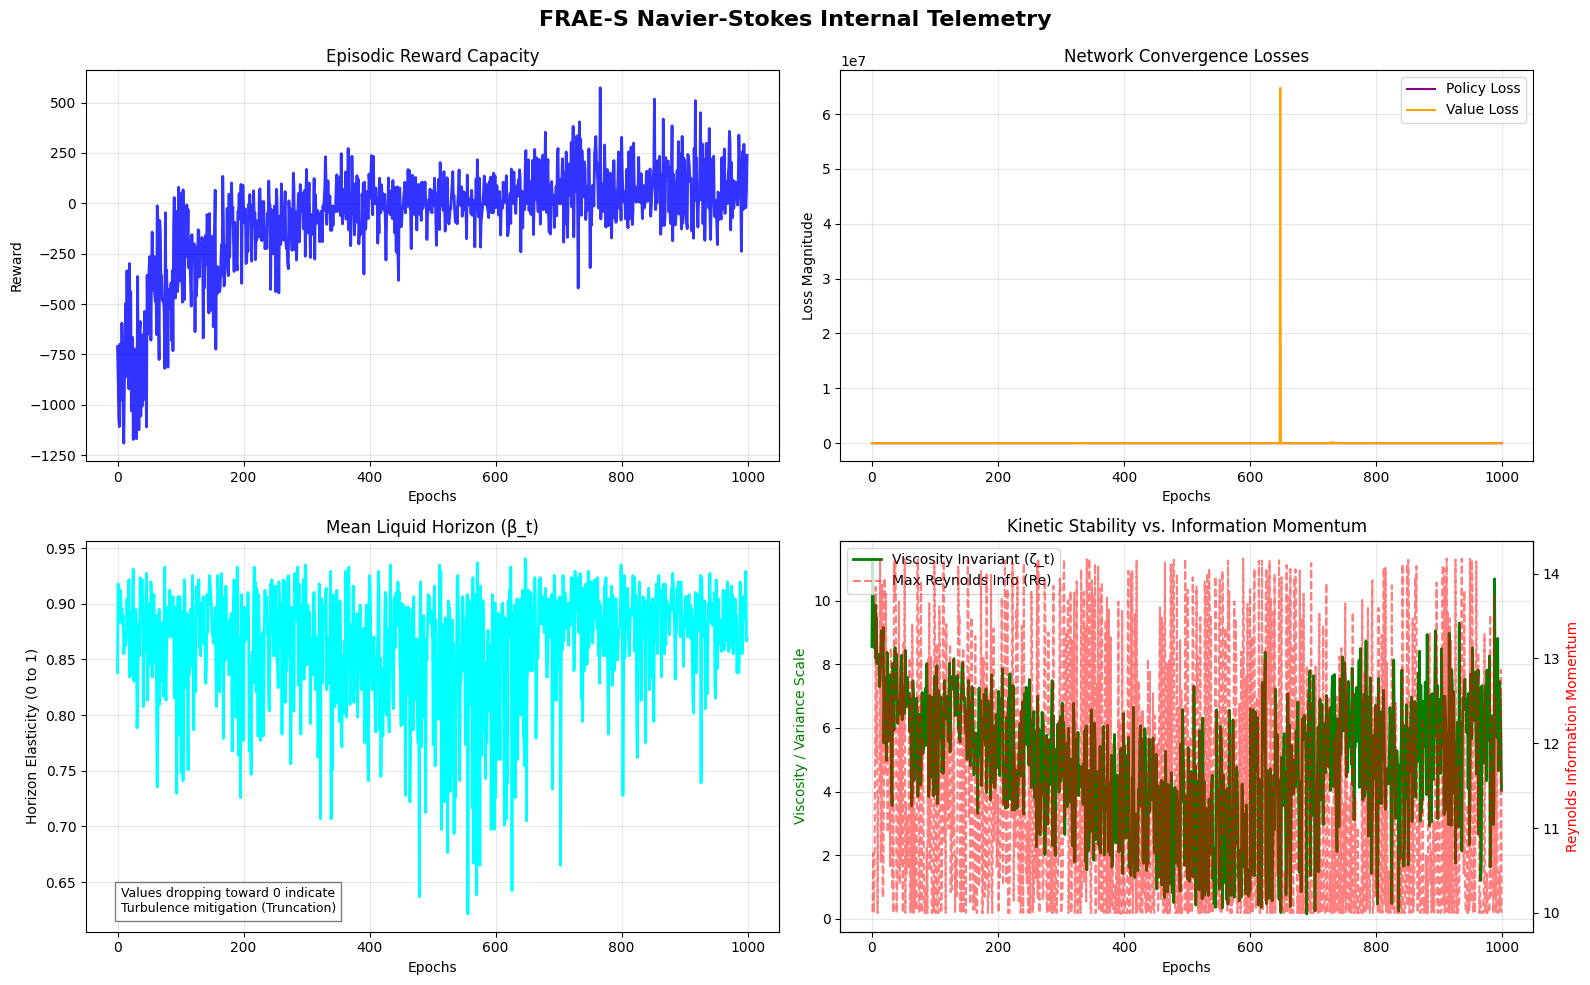

In [8]:
# Cell 8: Evaluating the Phase Transitions under High Variance
# We reuse the plotting function to observe the fluid dynamics

print("Rendering FRAE-S Physics Telemetry for LunarLander...")
plot_fraes_telemetry(ll_history)

In [6]:
# Cell 9: Fast, High-Complexity Topological Testing
print("Deploying Upgraded FRAE-S Architecture to Acrobot-v1...")

# Acrobot is highly non-linear (double pendulum) but trains very fast.
# We will use 500 epochs to observe the rapid convergence.
acro_model, acro_history = train_fraes_agent(
    env_name="Acrobot-v1",
    total_epochs=500,
    steps_per_epoch=500
)

print("Acrobot Training Complete.")

Deploying Upgraded FRAE-S Architecture to Acrobot-v1...
Initiating FRAE-S Training on Acrobot-v1 | Target Epochs: 500
Epoch 050 | Reward: -500.0 | Re_max: 10.00 | Zeta: 0.964 | Beta: 0.90
Epoch 100 | Reward: -497.0 | Re_max: 10.00 | Zeta: 1.202 | Beta: 0.84
Epoch 150 | Reward: -496.0 | Re_max: 10.00 | Zeta: 1.262 | Beta: 0.86
Epoch 200 | Reward: -496.0 | Re_max: 10.00 | Zeta: 1.350 | Beta: 0.92
Epoch 250 | Reward: -497.0 | Re_max: 10.00 | Zeta: 1.404 | Beta: 0.93
Epoch 300 | Reward: -496.0 | Re_max: 10.00 | Zeta: 1.913 | Beta: 0.92
Epoch 350 | Reward: -495.0 | Re_max: 10.24 | Zeta: 2.630 | Beta: 0.91
Epoch 400 | Reward: -494.0 | Re_max: 10.07 | Zeta: 2.744 | Beta: 0.90
Epoch 450 | Reward: -497.0 | Re_max: 10.16 | Zeta: 2.253 | Beta: 0.91
Epoch 500 | Reward: -495.0 | Re_max: 10.16 | Zeta: 2.915 | Beta: 0.91
Acrobot Training Complete.


Rendering FRAE-S Physics Telemetry for Acrobot...


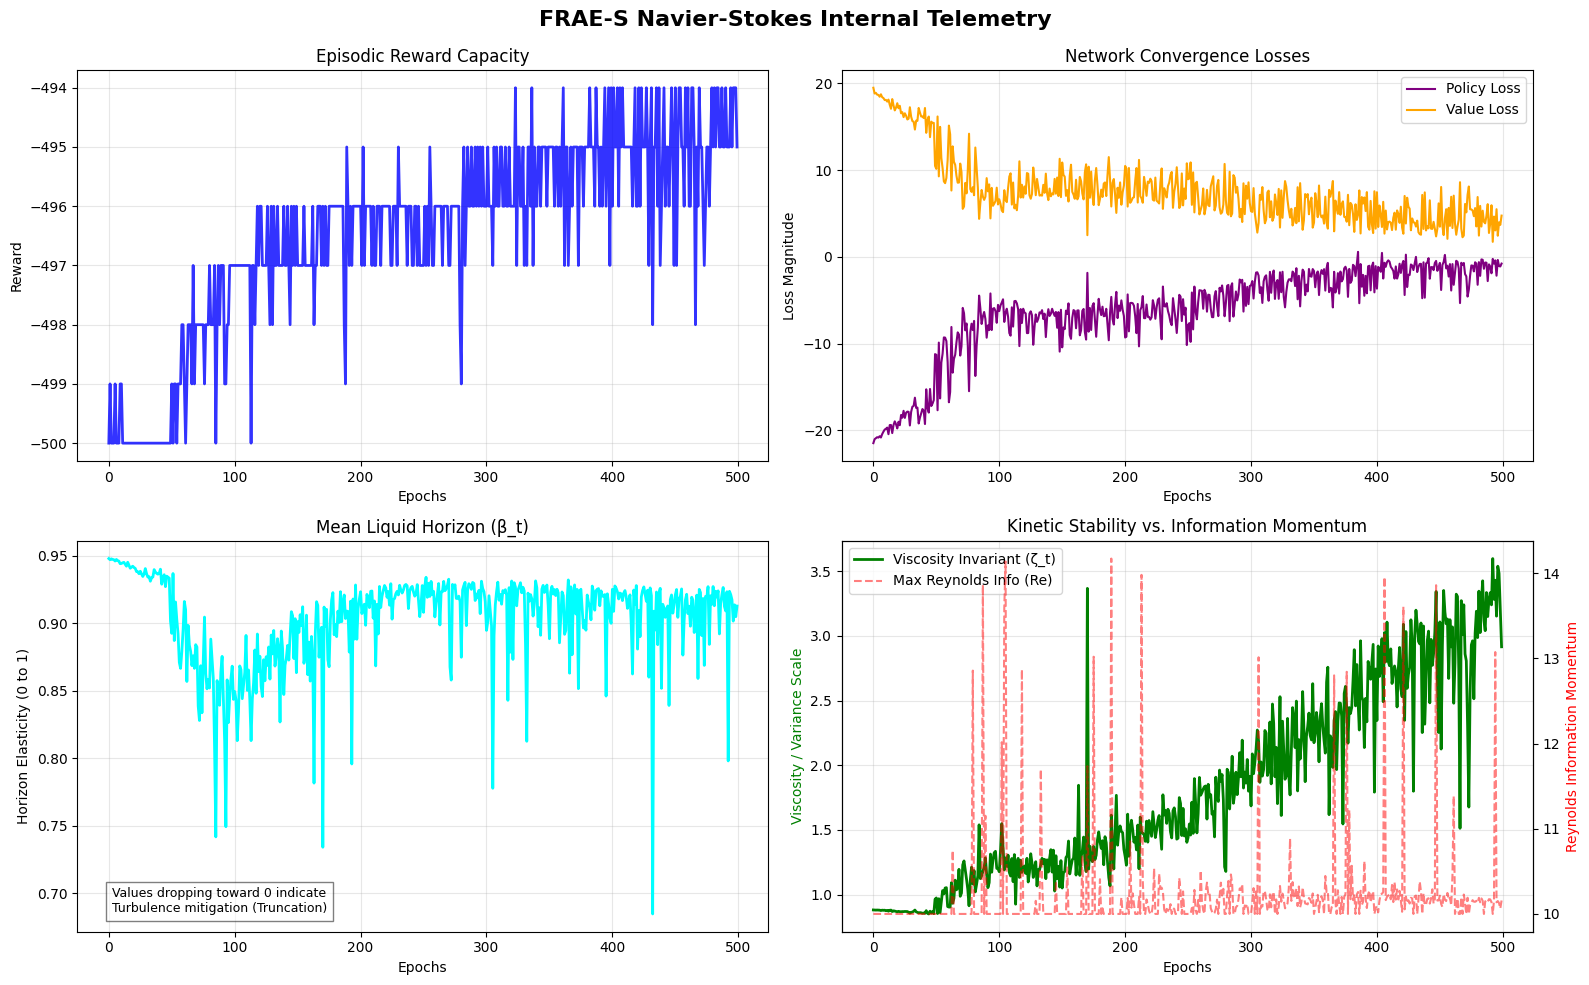

In [9]:
# Cell 10: Evaluating the Smooth Phase Transitions
import matplotlib.pyplot as plt
import numpy as np

def plot_fraes_telemetry(history):
    epochs = np.arange(len(history['rewards']))

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("FRAE-S Navier-Stokes Internal Telemetry", fontsize=16, fontweight='bold')

    # Plot 1: Standard Reward (Did it learn?)
    axs[0, 0].plot(epochs, history['rewards'], color='blue', alpha=0.8, linewidth=2)
    axs[0, 0].set_title("Episodic Reward Capacity")
    axs[0, 0].set_xlabel("Epochs")
    axs[0, 0].set_ylabel("Reward")
    axs[0, 0].grid(True, alpha=0.3)

    # Plot 2: Network Losses
    axs[0, 1].plot(epochs, history['policy_loss'], label="Policy Loss", color='purple')
    axs[0, 1].plot(epochs, history['value_loss'], label="Value Loss", color='orange')
    axs[0, 1].set_title("Network Convergence Losses")
    axs[0, 1].set_xlabel("Epochs")
    axs[0, 1].set_ylabel("Loss Magnitude")
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    # Plot 3: The Navier-Stokes Fluidity (β_t)
    axs[1, 0].plot(epochs, history['mean_beta'], color='cyan', linewidth=2)
    axs[1, 0].set_title("Mean Liquid Horizon (β_t)")
    axs[1, 0].set_xlabel("Epochs")
    axs[1, 0].set_ylabel("Horizon Elasticity (0 to 1)")
    axs[1, 0].text(0.05, 0.05, "Values dropping toward 0 indicate\nTurbulence mitigation (Truncation)",
                   transform=axs[1, 0].transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.5))
    axs[1, 0].grid(True, alpha=0.3)

    # Plot 4: The Stability Sink & Information Momentum
    ax4_twin = axs[1, 1].twinx()
    l1 = axs[1, 1].plot(epochs, history['mean_zeta'], color='green', label="Viscosity Invariant (ζ_t)", linewidth=2)
    l2 = ax4_twin.plot(epochs, history['max_re_info'], color='red', alpha=0.5, label="Max Reynolds Info (Re)", linestyle='--')

    axs[1, 1].set_title("Kinetic Stability vs. Information Momentum")
    axs[1, 1].set_xlabel("Epochs")
    axs[1, 1].set_ylabel("Viscosity / Variance Scale", color='green')
    ax4_twin.set_ylabel("Reynolds Information Momentum", color='red')

    # Combine legends for twin axes
    lns = l1 + l2
    labs = [l.get_label() for l in lns]
    axs[1, 1].legend(lns, labs, loc='upper left')
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

print("Rendering FRAE-S Physics Telemetry for Acrobot...")
plot_fraes_telemetry(acro_history)